<a href="https://colab.research.google.com/github/alexgohenghong/FRMS-Fatigue-Risk-Management-System-/blob/main/Aviation_Fatigue_Risk_Management_System_(FRMS)_Simulator_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
# ==============================================================================
# PHASE 1: Flight Roster Generation (EASA FTL Framework)
# Objective: Simulate a realistic monthly flight roster for a commercial airline
# ==============================================================================
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Simulate 5,000 flight sectors
def generate_flight_roster(n_flights=5000):
    np.random.seed(42)
    # Simulating departure hours (0-23)
    departure_hours = np.random.randint(0, 24, n_flights)
    # Simulating flight durations (1 to 14 hours)
    flight_durations = np.random.uniform(1, 14, n_flights)

    data = {
        'Flight_ID': [f'MH-{1000+i}' for i in range(n_flights)],
        'Departure_Hour_Local': departure_hours,
        'Flight_Duration_Hrs': np.round(flight_durations, 1),
        'Sectors_Flown_Today': np.random.randint(1, 4, n_flights)
    }
    return pd.DataFrame(data)

df_roster = generate_flight_roster()
print("✅ Phase 1 Complete: Flight Roster Dataset Generated (5,000 sectors).")
df_roster.head()

✅ Phase 1 Complete: Flight Roster Dataset Generated (5,000 sectors).


,Flight_ID,Departure_Hour_Local,Flight_Duration_Hrs,Sectors_Flown_Today
0,MH-1000,6,8.6,3
1,MH-1001,19,2.7,3
2,MH-1002,14,6.8,1
3,MH-1003,10,6.9,1
4,MH-1004,7,13.5,1


In [5]:
# ==============================================================================
# PHASE 2: WOCL & Fatigue Risk Scoring Engine
# Objective: Apply Window of Circadian Low (WOCL) penalties to calculate fatigue
# ==============================================================================

def calculate_fatigue_risk(df):
    # Base risk score relies on flight duration
    df['Base_Risk_Score'] = df['Flight_Duration_Hrs'] * 1.5

    # WOCL Penalty: Flights operating between 02:00 and 05:59 incur high physiological fatigue
    conditions = [
        (df['Departure_Hour_Local'] >= 2) & (df['Departure_Hour_Local'] <= 5),
        (df['Departure_Hour_Local'] >= 22) | (df['Departure_Hour_Local'] <= 1)
    ]
    choices = [10, 5] # +10 penalty for deep WOCL, +5 for late night
    df['WOCL_Penalty'] = np.select(conditions, choices, default=0)

    # Sector Penalty: More take-offs/landings = more fatigue
    df['Sector_Penalty'] = (df['Sectors_Flown_Today'] - 1) * 2

    # Total Fatigue Risk Score (FRS)
    df['Total_FRS'] = df['Base_Risk_Score'] + df['WOCL_Penalty'] + df['Sector_Penalty']

    # Risk Categorization
    bins = [0, 15, 25, 100]
    labels = ['Low Risk', 'Moderate Risk', 'CRITICAL RISK']
    df['Risk_Level'] = pd.cut(df['Total_FRS'], bins=bins, labels=labels)

    return df

df_risk = calculate_fatigue_risk(df_roster)
print("✅ Phase 2 Complete: EASA FTL & WOCL Logic Applied.")
df_risk[['Flight_ID', 'Departure_Hour_Local', 'Flight_Duration_Hrs', 'WOCL_Penalty', 'Total_FRS', 'Risk_Level']].head()

✅ Phase 2 Complete: EASA FTL & WOCL Logic Applied.


,Flight_ID,Departure_Hour_Local,Flight_Duration_Hrs,WOCL_Penalty,Total_FRS,Risk_Level
0,MH-1000,6,8.6,0,16.90,Moderate Risk
1,MH-1001,19,2.7,0,8.05,Low Risk
2,MH-1002,14,6.8,0,10.20,Low Risk
3,MH-1003,10,6.9,0,10.35,Low Risk
4,MH-1004,7,13.5,0,20.25,Moderate Risk


/tmp/ipykernel_21425/1216515303.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_risk, x='Risk_Level', palette={'Low Risk':'#2ca02c', 'Moderate Risk':'#ff7f0e', 'CRITICAL RISK':'#d62728'})


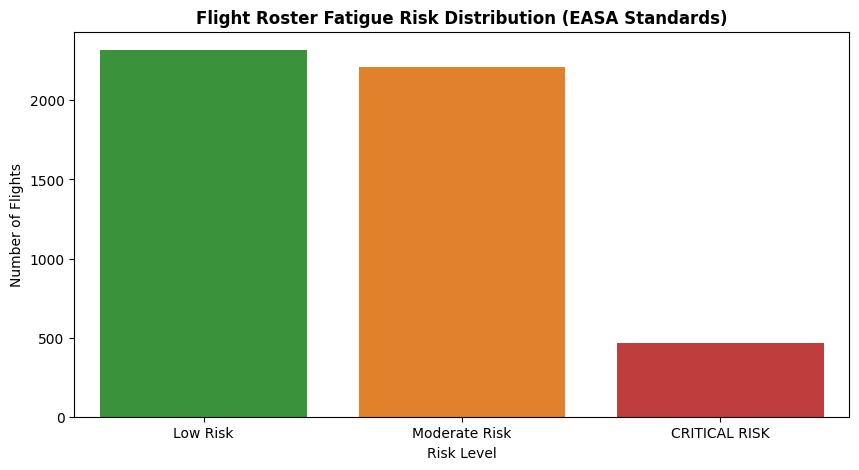


✈️ FLIGHT OPS SAFETY REPORT:
🚨 Critical Risk Flights Detected: 469 out of 5000 (9.4%)
✅ MITIGATION STRATEGY:
1. Flights flagged as 'CRITICAL RISK' primarily operate during the WOCL (02:00-05:59).
2. Recommendation: SOP dictates mandatory 'Heavy Crew' augmentation (3+ pilots) or controlled rest periods in flight.
3. System integration ready for Crew Rostering software to auto-flag EASA FTL violations.


In [6]:
# ==============================================================================
# PHASE 3: Operational Safety Insights & Mitigation Strategy
# Objective: Identify critical risk flights requiring crew augmentation (Heavy Crew)
# ==============================================================================

# Data Aggregation
critical_flights = df_risk[df_risk['Risk_Level'] == 'CRITICAL RISK']
critical_count = len(critical_flights)
total_count = len(df_risk)
critical_pct = (critical_count / total_count) * 100

# Visualization: Risk Distribution
plt.figure(figsize=(10, 5))
sns.countplot(data=df_risk, x='Risk_Level', palette={'Low Risk':'#2ca02c', 'Moderate Risk':'#ff7f0e', 'CRITICAL RISK':'#d62728'})
plt.title('Flight Roster Fatigue Risk Distribution (EASA Standards)', fontweight='bold')
plt.ylabel('Number of Flights')
plt.xlabel('Risk Level')
plt.show()

# Executive Summary
print("\n✈️ FLIGHT OPS SAFETY REPORT:")
print("=" * 70)
print(f"🚨 Critical Risk Flights Detected: {critical_count} out of {total_count} ({critical_pct:.1f}%)")
print("=" * 70)
print("✅ MITIGATION STRATEGY:")
print("1. Flights flagged as 'CRITICAL RISK' primarily operate during the WOCL (02:00-05:59).")
print("2. Recommendation: SOP dictates mandatory 'Heavy Crew' augmentation (3+ pilots) or controlled rest periods in flight.")
print("3. System integration ready for Crew Rostering software to auto-flag EASA FTL violations.")